In [1]:
! pip install opencv-python==4.10.0.84
import numpy as np
import cv2
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
path_to_data = "Desktop/tt/Python/Cricket celebritiy image classification/model/data_set"
path_to_cr_data = "Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/"

In [3]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_eye.xml'
)

In [4]:
import os
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)
img_dirs

['Desktop/tt/Python/Cricket celebritiy image classification/model/data_set\\Gautam_Gambhir',
 'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set\\Hardik_Pandya',
 'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set\\Jasprit_Bumrah',
 'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set\\MS_Dhoni',
 'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set\\Rohit_Sharma',
 'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set\\Sachin_Tendulkar',
 'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set\\Shubman_Gill',
 'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set\\Virat_Kohli',
 'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set\\Yashasvi_Jaiswal']

In [5]:
import shutil
if os.path.exists(path_to_cr_data):
     shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [6]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)

    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x, y, w, h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]

        eyes = eye_cascade.detectMultiScale(roi_gray)

        if len(eyes) >= 2:
            return roi_color

    return None

In [7]:
cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:
    count = 1

    celebrity_name = os.path.basename(img_dir)
    print(celebrity_name)

    celebrity_file_names_dict[celebrity_name] = []

    for entry in os.scandir(img_dir):

        roi_color = get_cropped_image_if_2_eyes(entry.path)

        if roi_color is not None:

            cropped_folder = os.path.join(
                path_to_cr_data,
                celebrity_name
            )

            if not os.path.exists(cropped_folder):
                os.makedirs(cropped_folder)
                cropped_image_dirs.append(cropped_folder)

                print(
                    "Generating cropped images in folder:",
                    cropped_folder
                )

            cropped_file_name = celebrity_name + str(count) + ".png"

            cropped_file_path = os.path.join(
                cropped_folder,
                cropped_file_name
            )

            cv2.imwrite(cropped_file_path, roi_color)

            celebrity_file_names_dict[
                celebrity_name
            ].append(cropped_file_path)

            count += 1

Gautam_Gambhir
Generating cropped images in folder: Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir
Hardik_Pandya
Generating cropped images in folder: Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Hardik_Pandya
Jasprit_Bumrah
Generating cropped images in folder: Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Jasprit_Bumrah
MS_Dhoni
Generating cropped images in folder: Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/MS_Dhoni
Rohit_Sharma
Generating cropped images in folder: Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Rohit_Sharma
Sachin_Tendulkar
Generating cropped images in folder: Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Sachin_Tendulkar
Shubman_Gill
Generating cropped images in folder: Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cro

In [8]:
import numpy as np
import pywt
import cv2    

def w2d(img, mode='haar', level=1):
    imArray = img
    #Datatype conversions
    #convert to grayscale
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    #convert to float
    imArray =  np.float32(imArray)   
    imArray /= 255;
    # compute coefficients 
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    #Process Coefficients
    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;  

    # reconstruction
    imArray_H=pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H =  np.uint8(imArray_H)

    return imArray_H


In [9]:
celebrity_file_names_dict = {}
for img_dir in cropped_image_dirs:
    celebrity_name = img_dir.split('/')[-1]
    file_list = []
    for entry in os.scandir(img_dir):
        file_list.append(entry.path)
    celebrity_file_names_dict[celebrity_name] = file_list
celebrity_file_names_dict

{'Gautam_Gambhir': ['Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir\\Gautam_Gambhir1.png',
  'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir\\Gautam_Gambhir10.png',
  'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir\\Gautam_Gambhir11.png',
  'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir\\Gautam_Gambhir12.png',
  'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir\\Gautam_Gambhir13.png',
  'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir\\Gautam_Gambhir14.png',
  'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir\\Gautam_Gambhir15.png',
  'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir\\Gautam_Gambhir16.png',

In [10]:
celebrity_file_names_dict.keys()

dict_keys(['Gautam_Gambhir', 'Hardik_Pandya', 'Jasprit_Bumrah', 'MS_Dhoni', 'Rohit_Sharma', 'Sachin_Tendulkar', 'Shubman_Gill', 'Virat_Kohli', 'Yashasvi_Jaiswal'])

In [13]:
cropped_img = cv2.imread(
    celebrity_file_names_dict['Gautam_Gambhir'][0]
)

In [14]:
print(cropped_img.shape)

(335, 335, 3)


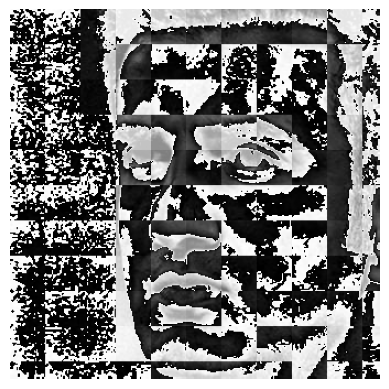

In [17]:
im_har = w2d(cropped_img, 'db1', 5)

plt.imshow(im_har, cmap='gray')
plt.axis('off');

In [18]:
celebrity_file_names_dict = {}
for img_dir in cropped_image_dirs:
    celebrity_name = img_dir.split('/')[-1]
    file_list = []
    for entry in os.scandir(img_dir):
        file_list.append(entry.path)
    celebrity_file_names_dict[celebrity_name] = file_list
celebrity_file_names_dict

{'Gautam_Gambhir': ['Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir\\Gautam_Gambhir1.png',
  'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir\\Gautam_Gambhir10.png',
  'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir\\Gautam_Gambhir11.png',
  'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir\\Gautam_Gambhir12.png',
  'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir\\Gautam_Gambhir13.png',
  'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir\\Gautam_Gambhir14.png',
  'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir\\Gautam_Gambhir15.png',
  'Desktop/tt/Python/Cricket celebritiy image classification/model/data_set/cropped/Gautam_Gambhir\\Gautam_Gambhir16.png',

In [19]:
class_dict = {}
count = 0
for celebrity_name in celebrity_file_names_dict.keys():
    class_dict[celebrity_name] = count
    count = count + 1
class_dict

{'Gautam_Gambhir': 0,
 'Hardik_Pandya': 1,
 'Jasprit_Bumrah': 2,
 'MS_Dhoni': 3,
 'Rohit_Sharma': 4,
 'Sachin_Tendulkar': 5,
 'Shubman_Gill': 6,
 'Virat_Kohli': 7,
 'Yashasvi_Jaiswal': 8}

In [20]:
X, y = [], []
for celebrity_name, training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        scalled_raw_img = cv2.resize(img, (32, 32))
        img_har = w2d(img,'db1',5)
        scalled_img_har = cv2.resize(img_har, (32, 32))
        combined_img = np.vstack((scalled_raw_img.reshape(32*32*3,1),scalled_img_har.reshape(32*32,1)))
        X.append(combined_img)
        y.append(class_dict[celebrity_name])     

In [21]:
X = np.array(X).reshape(len(X),4096).astype(float)
X.shape

(242, 4096)

In [22]:
X[0]

array([81., 65., 36., ...,  7., 55.,  3.], shape=(4096,))

In [23]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(kernel = 'rbf', C = 10))])
pipe.fit(X_train, y_train)
pipe.score(X_test, y_test)

0.4918032786885246

In [25]:
print(classification_report(y_test, pipe.predict(X_test)))

              precision    recall  f1-score   support

           0       0.46      0.86      0.60         7
           1       0.00      0.00      0.00         4
           2       0.56      1.00      0.71         5
           3       0.27      0.38      0.32         8
           4       0.67      0.29      0.40         7
           5       0.70      0.78      0.74         9
           6       0.83      0.42      0.56        12
           7       0.33      0.40      0.36         5
           8       0.00      0.00      0.00         4

    accuracy                           0.49        61
   macro avg       0.42      0.46      0.41        61
weighted avg       0.51      0.49      0.46        61



C:\Users\KRISHAN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\KRISHAN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\KRISHAN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [29]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV

In [30]:
model_params = {
    'svm': {
        'model': svm.SVC(gamma='auto',probability=True),
        'params' : {
            'svc__C': [1,10,100,1000],
            'svc__kernel': ['rbf','linear']
        }  
    },
    'random_forest': {
        'model': RandomForestClassifier(),
        'params' : {
            'randomforestclassifier__n_estimators': [1,5,10]
        }
    },
    'logistic_regression' : {
        'model': LogisticRegression(solver='lbfgs'),
        'params': {
            'logisticregression__C': [1,5,10]
        }
    }
}

In [31]:
scores = []
best_estimators = {}
import pandas as pd
for algo, mp in model_params.items():
    pipe = make_pipeline(StandardScaler(), mp['model'])
    clf =  GridSearchCV(pipe, mp['params'], cv=5, return_train_score=False)
    clf.fit(X_train, y_train)
    scores.append({
        'model': algo,
        'best_score': clf.best_score_,
        'best_params': clf.best_params_
    })
    best_estimators[algo] = clf.best_estimator_
    
df = pd.DataFrame(scores,columns=['model','best_score','best_params'])
df

,model,best_score,best_params
0,svm,0.635435,"{'svc__C': 1, 'svc__kernel': 'linear'}"
1,random_forest,0.392342,{'randomforestclassifier__n_estimators': 10}
2,logistic_regression,0.657508,{'logisticregression__C': 1}


In [36]:
#best_estimators

In [40]:
svm_clf = best_estimators['svm']

In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, svm_clf.predict(X_test))

cm

array([[6, 0, 0, 1, 0, 0, 0, 0, 0],
       [0, 0, 1, 2, 0, 0, 0, 1, 0],
       [0, 0, 5, 0, 0, 0, 0, 0, 0],
       [2, 0, 0, 4, 0, 1, 1, 0, 0],
       [0, 1, 1, 0, 5, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 8, 0, 0, 1],
       [3, 0, 0, 1, 0, 0, 6, 0, 2],
       [0, 0, 1, 1, 1, 0, 0, 2, 0],
       [1, 0, 0, 0, 0, 0, 1, 0, 2]])

Text(95.72222222222221, 0.5, 'Truth')

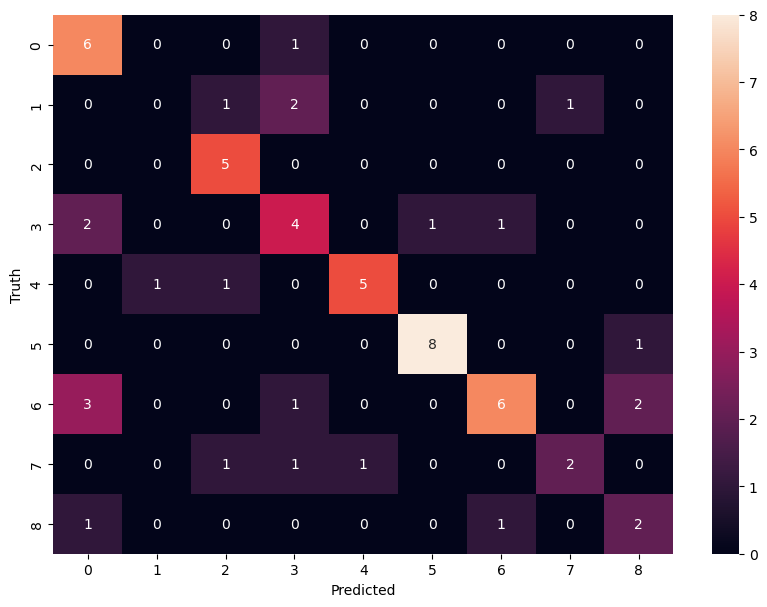

In [42]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [43]:
class_dict

{'Gautam_Gambhir': 0,
 'Hardik_Pandya': 1,
 'Jasprit_Bumrah': 2,
 'MS_Dhoni': 3,
 'Rohit_Sharma': 4,
 'Sachin_Tendulkar': 5,
 'Shubman_Gill': 6,
 'Virat_Kohli': 7,
 'Yashasvi_Jaiswal': 8}

In [44]:
!pip install joblib
import joblib 
# Save the model as a pickle in a file 
joblib.dump(best_clf, 'saved_model.pkl') 

['saved_model.pkl']

In [45]:
import json
with open("class_dictionary.json","w") as f:
    f.write(json.dumps(class_dict))